<a href="https://colab.research.google.com/github/grgpratibha/test/blob/master/scrape_HarryporterSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

scrape information from the [WAR List](https://en.wikipedia.org/wiki/List_of_wars:_before_1000)

## installing necessary modules

In [1]:
! pip install requests beautifulsoup4
! pip install nltk wordcloud

## Mount the drive and set the working directory

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks')

## Start scraping data from wikipedia page using requests and BeautiulSoup

In [4]:
# import the necessary modules
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import re
import matplotlib.pyplot as plt

from collections import Counter
import string
import pandas as pd

In [5]:
# get the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Browser's Developer Tool -> inspect element -> style class of desired table??

can we use any of the following?

```
soup.find_all('table', class_='wikiepisodetable')  

soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

soup.find_all('table', attrs={'class': ['wikitable', 'wikiepisodetable']})

```

In [37]:
# Define our functions here
def save_episode_data( html_soup):

    episodes = []
    #ep_tables = html_soup.find_all('table', class_='wikiepisodetable')
    ep_tables = html_soup.find_all('table', class_='wikitable sortable')

    for table in ep_tables:
        headers = []
        rows = table.find_all('tr')
    # Start by fetching the header cells from the first row to determine
    # the field names
        for header in table.find('tr').find_all('th'):
            headers.append(header.text.strip()) # Added strip() to remove leading/trailing whitespace
    # print(headers)
    # Then go through all the rows except the first one
        for row in table.find_all('tr')[1:]:
            values = []
            # And get the column cells, the first one being inside a th-tag
            for col in row.find_all(['th','td']):
                values.append(col.text.strip()) # Added strip() to remove leading/trailing whitespace
            # Check if the number of values matches the number of headers before creating the dictionary
            if values and len(values) == len(headers):
                episode_dict = {}
                for i in range(len(values)):
                  episode_dict[headers[i]]= values[i]
                episodes.append(episode_dict)

    return episodes


# display word cloud from text
def print_wordcloud(str_text):

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(str_text)
    # now display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    return

# function to extract specific field values
def get_field_episodes(field_name, episodes):
    str_text = ''
    list_values = [(dd.get(field_name, 'N/A')) for dd in episodes]
    for tt in list_values:
        if tt != 'N/A':
            str_text += tt + ' '
    return str_text

#load saved file
def read_html_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            html_content = file.read()
        return html_content
    except FileNotFoundError:
        print(f"File '{file_path}' not found.")
        return None


# read the text from the HTML content
def extract_text_from_html(html_content):

    soup = BeautifulSoup(html_content, 'html.parser')
    soup_text = soup.get_text()

    return soup_text


# Now, clean the text by removing stopwords and special characters
def clean_text(text):

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()  # change to lowercase

    # tokenize the text and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

    # finally, join the filtered words back into a single string
    filtered_text = " ".join(filtered_words)

    return filtered_text



def get_top_n_words(text, n=10):
    # Convert text to lowercase and remove punctuation
    text = text.lower().translate(str.maketrans('', '', string.punctuation))

    # Tokenize the text into words
    words = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # Count word frequencies
    word_freq = Counter(filtered_words)

    # Return the top N most common words
    return word_freq.most_common(n)

Lets do the webscraping and processing the data

In [42]:
#1. scrape the URL and save the html contents
url = "https://en.wikipedia.org/wiki/Harry_Potter_(film_series)" # Changed URL to the WAR List
response = requests.get(url)
if response.status_code != 200:
    exit()


html_contents = response.text
# save the html page contents ie write mode
with open("harryporter_series.html", "w", encoding="utf-8") as file: # Changed filename
    file.write(html_contents)
print("HTML Page's content saved locally to 'harryporter_series.html'.") # Changed filename


html_soup = BeautifulSoup(html_contents, 'html.parser')

# Storing the episode list
episodes = save_episode_data( html_soup)

# Show the results

for i in range(len(episodes)):
    print(episodes[i])
    break # if we want to print all data then comment this line

HTML Page's content saved locally to 'harryporter_series.html'.
{'Film': "Philosopher's Stone", 'Rotten Tomatoes': '81% (7.06/10 average rating) (200 reviews)[95]', 'Metacritic': '65 (37 reviews)[96]', 'CinemaScore[94]': 'A'}


## Using pickle to dump the data in 'episodes'

In [56]:
import pickle
# Filepath to save the pickle file
pickle_file = "harryporter_series.pkl"

# Save the `episodes` list to a pickle file
with open(pickle_file, "wb") as file:
    pickle.dump(episodes, file)

pickle_file

'harryporter_series.pkl'

## Loding the 'episodes' back

In [57]:
# Step 3: Loading Variables
loaded_episodes = None

# Open the file in binary mode
with open(pickle_file, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_episodes = pickle.load(file)

print("The variable 'data' has been loaded successfully.")

print("Loaded Data:", loaded_episodes)

The variable 'data' has been loaded successfully.
Loaded Data: [{'Film': "Philosopher's Stone", 'Rotten Tomatoes': '81% (7.06/10 average rating) (200 reviews)[95]', 'Metacritic': '65 (37 reviews)[96]', 'CinemaScore[94]': 'A'}, {'Film': 'Chamber of Secrets', 'Rotten Tomatoes': '82% (7.21/10 average rating) (237 reviews)[97]', 'Metacritic': '63 (35 reviews)[98]', 'CinemaScore[94]': 'A+'}, {'Film': 'Prisoner of Azkaban', 'Rotten Tomatoes': '90% (7.85/10 average rating) (258 reviews)[99]', 'Metacritic': '82 (40 reviews)[100]', 'CinemaScore[94]': 'A'}, {'Film': 'Order of the Phoenix', 'Rotten Tomatoes': '78% (6.9/10 average rating) (256 reviews)[103]', 'Metacritic': '71 (37 reviews)[104]', 'CinemaScore[94]': 'A−'}, {'Film': 'Deathly Hallows – Part 1', 'Rotten Tomatoes': '77% (7.09/10 average rating) (288 reviews)[107]', 'Metacritic': '65 (42 reviews)[108]', 'CinemaScore[94]': 'A'}]


In [58]:
# lets display some loaded data
loaded_episodes[:1]

[{'Film': "Philosopher's Stone",
  'Rotten Tomatoes': '81% (7.06/10 average rating) (200 reviews)[95]',
  'Metacritic': '65 (37 reviews)[96]',
  'CinemaScore[94]': 'A'}]

In [59]:
# lets display some loaded data
loaded_episodes[:2]

[{'Film': "Philosopher's Stone",
  'Rotten Tomatoes': '81% (7.06/10 average rating) (200 reviews)[95]',
  'Metacritic': '65 (37 reviews)[96]',
  'CinemaScore[94]': 'A'},
 {'Film': 'Chamber of Secrets',
  'Rotten Tomatoes': '82% (7.21/10 average rating) (237 reviews)[97]',
  'Metacritic': '63 (35 reviews)[98]',
  'CinemaScore[94]': 'A+'}]

In [60]:
# lets display some loaded data
loaded_episodes[:4]

[{'Film': "Philosopher's Stone",
  'Rotten Tomatoes': '81% (7.06/10 average rating) (200 reviews)[95]',
  'Metacritic': '65 (37 reviews)[96]',
  'CinemaScore[94]': 'A'},
 {'Film': 'Chamber of Secrets',
  'Rotten Tomatoes': '82% (7.21/10 average rating) (237 reviews)[97]',
  'Metacritic': '63 (35 reviews)[98]',
  'CinemaScore[94]': 'A+'},
 {'Film': 'Prisoner of Azkaban',
  'Rotten Tomatoes': '90% (7.85/10 average rating) (258 reviews)[99]',
  'Metacritic': '82 (40 reviews)[100]',
  'CinemaScore[94]': 'A'},
 {'Film': 'Order of the Phoenix',
  'Rotten Tomatoes': '78% (6.9/10 average rating) (256 reviews)[103]',
  'Metacritic': '71 (37 reviews)[104]',
  'CinemaScore[94]': 'A−'}]

## Lets display the wordclouds

In [73]:
str_titles = get_field_episodes('Film', loaded_episodes)
print(str_titles)
str_desc = get_field_episodes('Rotten Tomatoes', loaded_episodes) # check if this filed can get the descriptions!!!
print(str_desc)


Philosopher's Stone Chamber of Secrets Prisoner of Azkaban Order of the Phoenix Deathly Hallows – Part 1 
81% (7.06/10 average rating) (200 reviews)[95] 82% (7.21/10 average rating) (237 reviews)[97] 90% (7.85/10 average rating) (258 reviews)[99] 78% (6.9/10 average rating) (256 reviews)[103] 77% (7.09/10 average rating) (288 reviews)[107] 


Wordclouds of Titles only


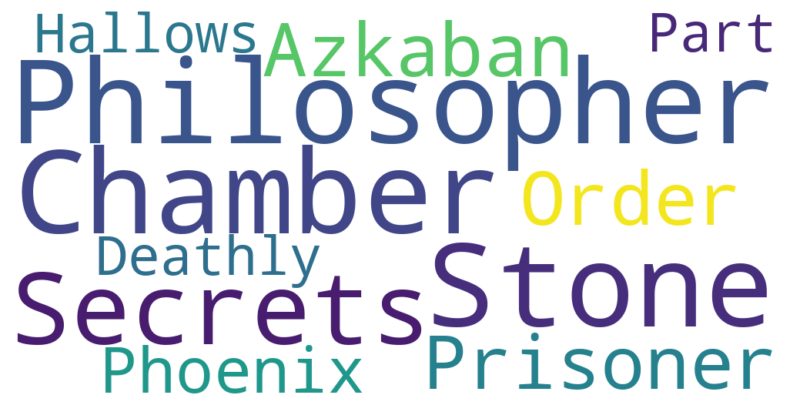

In [70]:
print ("Wordclouds of Titles only")
print_wordcloud(str_titles)



Wordclouds of Description 


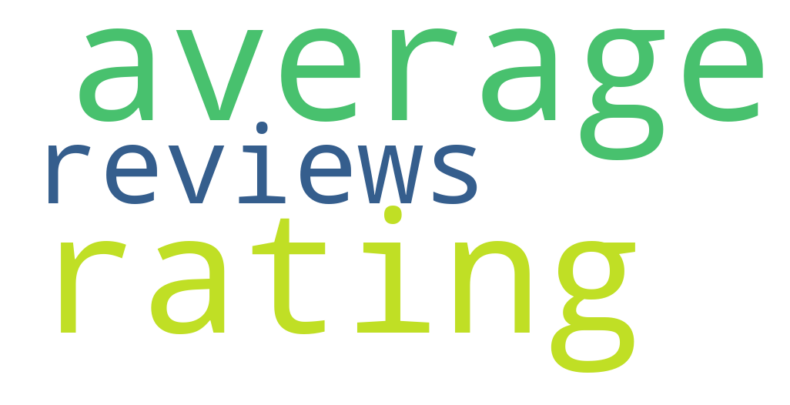

In [74]:
print ("Wordclouds of Description ")
print_wordcloud(str_desc)


Wordclouds of Titles and Description


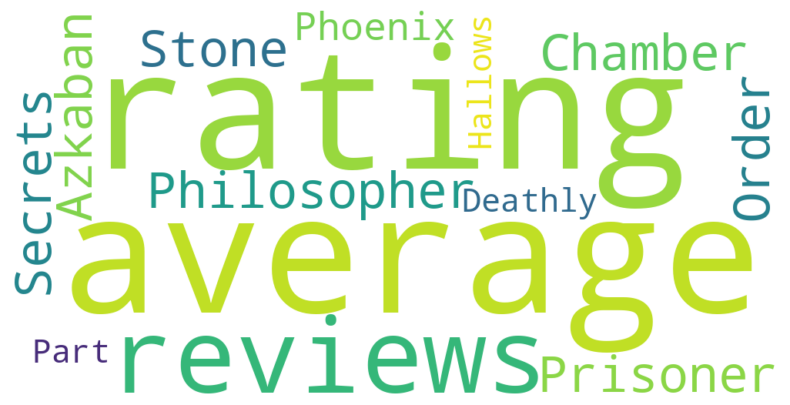

In [75]:

print ("Wordclouds of Titles and Description")
print_wordcloud(str_titles +' '+ str_desc)

In [76]:

# Convert  list of dictionaries (loaded_episodes) into a pandas DataFrame.
# Parameters: episodloaded_episodeses (list): List of dictionaries, where each dictionary is an episode with fields.

df_episode= pd.DataFrame(loaded_episodes)
df_episode.head()

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94]
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A
1,Chamber of Secrets,82% (7.21/10 average rating) (237 reviews)[97],63 (35 reviews)[98],A+
2,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A
3,Order of the Phoenix,78% (6.9/10 average rating) (256 reviews)[103],71 (37 reviews)[104],A−
4,Deathly Hallows – Part 1,77% (7.09/10 average rating) (288 reviews)[107],65 (42 reviews)[108],A


#above df_episode are having NAN values so need data processing or cleaning features.

step 1.  clean dataframe

step 2: features and Target

step 3: Vectorize text

Step 4: Scale numerical data

step 5: combine text

step 6: smote

Step 7: train test split

Step 8: Train classifier

Step 9: Predict and Evaluate



In [77]:
# DataPreprocessing: data cleaning on df_episode

import pandas as pd
# Display initial information about the DataFrame
print("Initial DataFrame Info:")
df_episode.info()

# Display the first few rows of the DataFrame
print("\nInitial DataFrame Head:")
print(df_episode.head())

# Display descriptive statistics for numerical columns
print("\nInitial DataFrame Description:")
print(df_episode.describe())

# Check for duplicate rows and drop them
print("\nChecking for and removing duplicate rows...")
initial_rows = df_episode.shape[0]
df_episode.drop_duplicates(inplace=True)
rows_after_dropping_duplicates = df_episode.shape[0]
print(f"Removed {initial_rows - rows_after_dropping_duplicates} duplicate rows.")

# Check for missing values
print("\nMissing values before handling:")
print(df_episode.isnull().sum())

# Example of handling missing values: fill missing values in 'Air date' with a placeholder
# (Adjust this based on how you want to handle missing values for each column)
if 'Air date' in df_episode.columns:
    df_episode['Air date'].fillna('Unknown', inplace=True)

# Example of converting data types: convert 'No. overall' and 'No. in season' to numeric
# It's important to handle potential errors during conversion (e.g., non-numeric values)
for col in ['No. overall', 'No. in season']:
    if col in df_episode.columns:
        df_episode[col] = pd.to_numeric(df_episode[col], errors='coerce')
        # After coercing errors, you might have NaNs for values that couldn't be converted.
        # Decide how to handle these NaNs (e.g., fill, drop rows, etc.)
        # For example, filling with 0:
        # df_episode[col].fillna(0, inplace=True)

# Example of standardizing column names (optional, but good practice)
df_episode.columns = [col.strip().replace(' ', '_').lower() for col in df_episode.columns]
print("\nColumn names after standardization:")
print(df_episode.columns)


# Perform further data cleaning specific to potential issues in this dataset:

# 1. Clean the 'title' column: remove trailing whitespace and newlines
if 'title' in df_episode.columns:
    df_episode['title'] = df_episode['title'].str.strip()

# 2. Clean the 'air_date' column: Try to convert to datetime objects
# This is crucial for time-based analysis
if 'air_date' in df_episode.columns:
    # Attempt to convert 'air_date' to datetime, coercing errors to NaT (Not a Time)
    df_episode['air_date'] = pd.to_datetime(df_episode['air_date'], errors='coerce')
    # You can then decide how to handle the rows where conversion failed (NaT values)
    print(f"\nNumber of rows with invalid 'air_date' after conversion: {df_episode['air_date'].isnull().sum()}")
    # Example: Dropping rows with invalid dates (be cautious, assess if this is appropriate)
    # df_episode.dropna(subset=['air_date'], inplace=True)

# 3. Clean the 'no._overall' and 'no._in_season' columns if they weren't properly converted
# This part re-checks and handles potential non-numeric entries again
for col in ['no._overall', 'no._in_season']:
    if col in df_episode.columns:
        # Ensure they are numeric, coercing errors will turn invalid values into NaN
        df_episode[col] = pd.to_numeric(df_episode[col], errors='coerce')
        # Fill resulting NaNs if necessary (e.g., with a marker value or the median/mean)
        # print(f"Missing values in {col} after conversion: {df_episode[col].isnull().sum()}")
        # Example: fill NaNs with -1 to indicate missing/invalid number
        # df_episode[col].fillna(-1, inplace=True)


# Display info and head of the cleaned DataFrame
print("\nCleaned DataFrame Info:")
df_episode.info()

print("\nCleaned DataFrame Head:")
print(df_episode.head())

print("\nMissing values after handling:")
print(df_episode.isnull().sum())

# Optional: Save the cleaned DataFrame
# df_episode.to_csv('mayday_episodes_cleaned.csv', index=False)
# print("\nCleaned DataFrame saved to 'mayday_episodes_cleaned.csv'")


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Film             5 non-null      object
 1   Rotten Tomatoes  5 non-null      object
 2   Metacritic       5 non-null      object
 3   CinemaScore[94]  5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes

Initial DataFrame Head:
                       Film                                  Rotten Tomatoes  \
0       Philosopher's Stone   81% (7.06/10 average rating) (200 reviews)[95]   
1        Chamber of Secrets   82% (7.21/10 average rating) (237 reviews)[97]   
2       Prisoner of Azkaban   90% (7.85/10 average rating) (258 reviews)[99]   
3      Order of the Phoenix   78% (6.9/10 average rating) (256 reviews)[103]   
4  Deathly Hallows – Part 1  77% (7.09/10 average rating) (288 reviews)[107]   

             Metacritic CinemaScore[94]  
0   65 (37 re

In [78]:
df_episode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   film             5 non-null      object
 1   rotten_tomatoes  5 non-null      object
 2   metacritic       5 non-null      object
 3   cinemascore[94]  5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes


In [79]:
import pandas as pd

def convert_to_dataframe_with_description(episodes):
    """
    Converts list of dictionaries to a cleaned DataFrame by extracting descriptions
    from alternate rows and assigning them to a new 'Description' column.

    Parameters:
        episodes (list): List of dictionaries parsed from web.

    Returns:
        pd.DataFrame: Cleaned DataFrame with descriptions properly assigned.
    """
    # Step 1: Convert to DataFrame
    df = pd.DataFrame(episodes)

    # Step 2: Reset index in case it's not default
    df.reset_index(drop=True, inplace=True)

    # Step 3: Create empty column 'Description'
    df['Description'] = None

    # Step 4: Loop through even rows and pull description from the next row (if available)
    for i in range(0, len(df), 2):
        if i+1 < len(df) and pd.isna(df.iloc[i+1, 1]):  # Assuming 1st col of description row is not numeric
            df.at[i, 'Description'] = str(df.iloc[i+1, 0]).strip()

    # Step 5: Drop the odd-numbered rows (1, 3, 5, ...) containing only descriptions
    df_cleaned = df.drop(index=[i for i in range(1, len(df), 2)])

    # Step 6: Reset index
    df_cleaned.reset_index(drop=True, inplace=True)

    return df_cleaned
df_episode = convert_to_dataframe_with_description(loaded_episodes)
df_episode.head()

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None
2,Deathly Hallows – Part 1,77% (7.09/10 average rating) (288 reviews)[107],65 (42 reviews)[108],A,None


In [80]:
df_episode.to_csv('harryporter_series.csv', index=False)

Word Cloud from entire html text


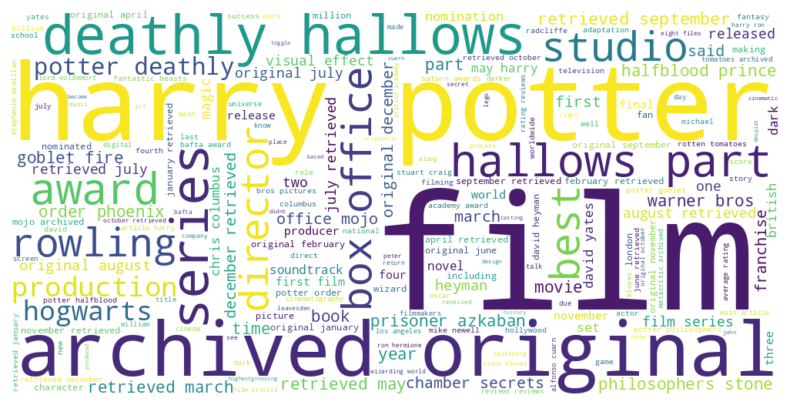

In [81]:
# laod the saved HTML content from 'mayday_episodes.html'

# Step 1: Read the HTML file
saved_file ='harryporter_series.html'
html_content = read_html_file(saved_file)
text = extract_text_from_html(html_content)
cleaned_text = clean_text(text)

print ("Word Cloud from entire html text")
print_wordcloud(cleaned_text)



In [82]:

print ("Most frequent 5 words")
top_5_words = get_top_n_words(cleaned_text, n=5)
print(top_5_words)


print ("Most frequent 10 words")
top_10_words = get_top_n_words(cleaned_text, n=10)
print(top_10_words)

Most frequent 5 words
[('harry', 257), ('potter', 254), ('film', 171), ('original', 161), ('retrieved', 161)]
Most frequent 10 words
[('harry', 257), ('potter', 254), ('film', 171), ('original', 161), ('retrieved', 161), ('archived', 159), ('films', 136), ('series', 81), ('hallows', 72), ('deathly', 69)]


## lets play with our existing dataframe


In [83]:
df = df_episode #Both point to the same object (changes in df affect df_episode).



In [84]:
df = df_episode.copy() # Creates a new, independent copy (safe from modifying the original).


In [85]:
df.head()

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None
2,Deathly Hallows – Part 1,77% (7.09/10 average rating) (288 reviews)[107],65 (42 reviews)[108],A,None


In [88]:
df.head(2)


,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None


In [91]:
df.tail(3)

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None
2,Deathly Hallows – Part 1,77% (7.09/10 average rating) (288 reviews)[107],65 (42 reviews)[108],A,None


In [86]:
# lets remove a column
df.drop('No.', axis=1, inplace=True)


KeyError: "['No.'] not found in axis"

In [92]:
# SLICING
df.loc[0:2,'Film']

,Film
0,Philosopher's Stone
1,Prisoner of Azkaban
2,Deathly Hallows – Part 1


In [93]:
# SLICING
df.loc[2:5,'Film']

,Film
2,Deathly Hallows – Part 1


In [94]:
# SLICING
df.iloc[0:2,1]

,Rotten Tomatoes
0,81% (7.06/10 average rating) (200 reviews)[95]
1,90% (7.85/10 average rating) (258 reviews)[99]


In [95]:
# SLICING
df.iloc[0:2,:]

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None


In [97]:
# SLICING
df.iloc[:,0:5]

,Film,Rotten Tomatoes,Metacritic,CinemaScore[94],Description
0,Philosopher's Stone,81% (7.06/10 average rating) (200 reviews)[95],65 (37 reviews)[96],A,None
1,Prisoner of Azkaban,90% (7.85/10 average rating) (258 reviews)[99],82 (40 reviews)[100],A,None
2,Deathly Hallows – Part 1,77% (7.09/10 average rating) (288 reviews)[107],65 (42 reviews)[108],A,None


data cleaning and then

what can be done??date engineering
i.e seeing -> fatalities_count, date, aircraft type, error type

what could be input here??
date, aircraft type, error type

output??
fatalities_count

what other could be done??
1.  designing model for above input and output,
2.  defining accident type,
3. aircraft model and age,
4. weather conditions (if applicable)
5. Accident severity prediction (eg: Low/ Medium/ High)
Features:
*   Structued: Fatalities count, accident type(mechanical/human error)
*   Text: Episodes summaries (TF- IDF (top frequency- inverse document frequency), word embedding)
*   Temporal: Air date (seasonality effects)


Validation??

Generalization TEst Dataset: Aviation Safety Network (ASN)
[link for aviation safety network](https://asn.flightsafety.org/database/)


outcome from above:






Data balancing using SMOTE and check classification report
Create Confusion matrix, diagonal value should be non-zero value.

*   i.e perform from step 6 to 9 of data cleaning section


